<a href="https://colab.research.google.com/github/sumitkharayat/Machine-learning-work/blob/main/Spam%20email%20classification%20model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

Convert Labels to Numeric

0 → Not Spam
1 → Spam

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Applied ML lab/Exp-5,6,7,8 Data and Question-20260301/spam_email.csv", encoding='latin-1')

df = df[['Category', 'Message']]
df.columns = ['label', 'message']

print(df.head())
print(df.shape)

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
(5572, 2)


In [ ]:
df['label'] = df['label'].map({'ham':0, 'spam':1})

In [ ]:
# Feature & Target Separation
X = df['message']
y = df['label']

 Text Vectorization (TF-IDF)

Machine learning models cannot understand raw text.
We convert text → numerical vectors.

In [ ]:
vectorizer = TfidfVectorizer(stop_words='english')

X = vectorizer.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train & Compare Models

In [ ]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Support Vector Machine": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=200)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print("\n", "="*40)
    print("Model:", name)
    print("Accuracy:", acc)
    print("Classification Report:\n", classification_report(y_test, y_pred))


Model: Naive Bayes
Accuracy: 0.9775784753363229
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       966
           1       1.00      0.83      0.91       149

    accuracy                           0.98      1115
   macro avg       0.99      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115


Model: Logistic Regression
Accuracy: 0.9560538116591928
Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98       966
           1       1.00      0.67      0.80       149

    accuracy                           0.96      1115
   macro avg       0.98      0.84      0.89      1115
weighted avg       0.96      0.96      0.95      1115


Model: Support Vector Machine
Accuracy: 0.9775784753363229
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       966

Compare Accuracy

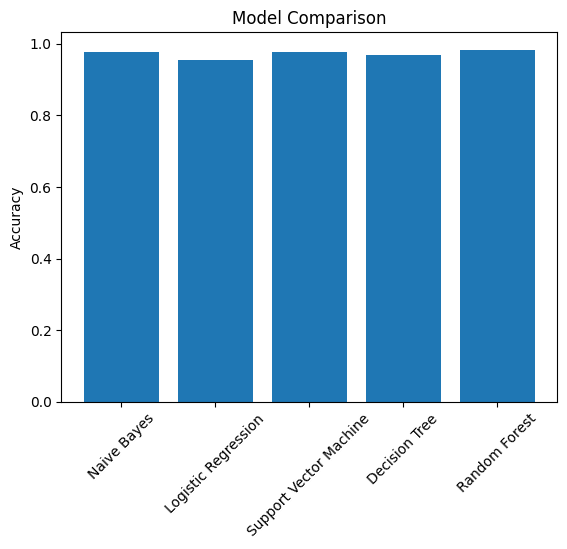

In [ ]:
plt.figure()
plt.bar(results.keys(), results.values())
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

Best Model: Random Forest


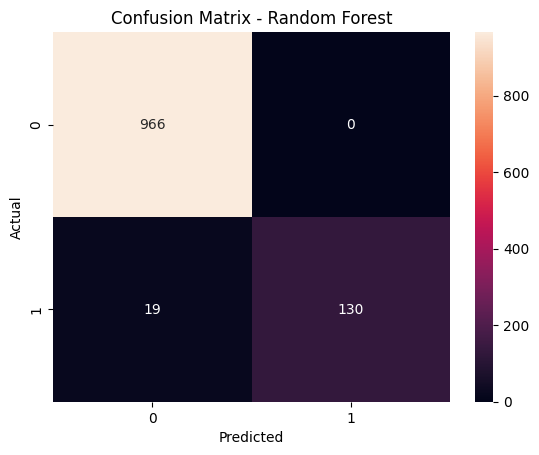

In [ ]:
best_model_name = max(results, key=results.get)
print("Best Model:", best_model_name)

best_model = models[best_model_name]
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - " + best_model_name)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()